In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"

Abrimos el vídeo

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {VIDEO_PATH}")

print("Video abierto correctamente.")

Video abierto correctamente.


Sacamos los fps, la cantidad de frames, ancho y alto, duración. 

In [4]:
fps = cap.get(cv2.CAP_PROP_FPS)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = n_frames / fps

print(f"Resolución: {width} × {height} píxeles")
print(f"FPS: {fps:.2f}")
print(f"Cantidad de frames: {n_frames}")
print(f"Duración: {duration:.2f} segundos")

Resolución: 1920 × 1080 píxeles
FPS: 29.98
Cantidad de frames: 956
Duración: 31.89 segundos


Tomamos el frame representativo desde la mitad del video. 

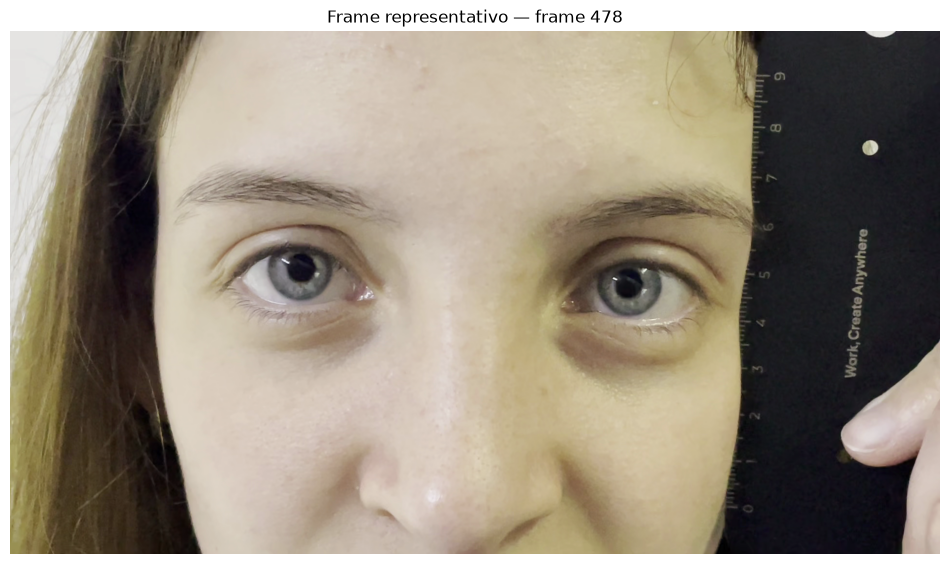

In [5]:
frame_index = n_frames // 2

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
ret, frame_bgr = cap.read()

if not ret:
    raise RuntimeError("No se pudo leer el frame seleccionado.")

# OpenCV utiliza BGR; Matplotlib utiliza RGB
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)
plt.title(f"Frame representativo — frame {frame_index}")
plt.axis("off")
plt.show()

Ahora elegimos el ROI

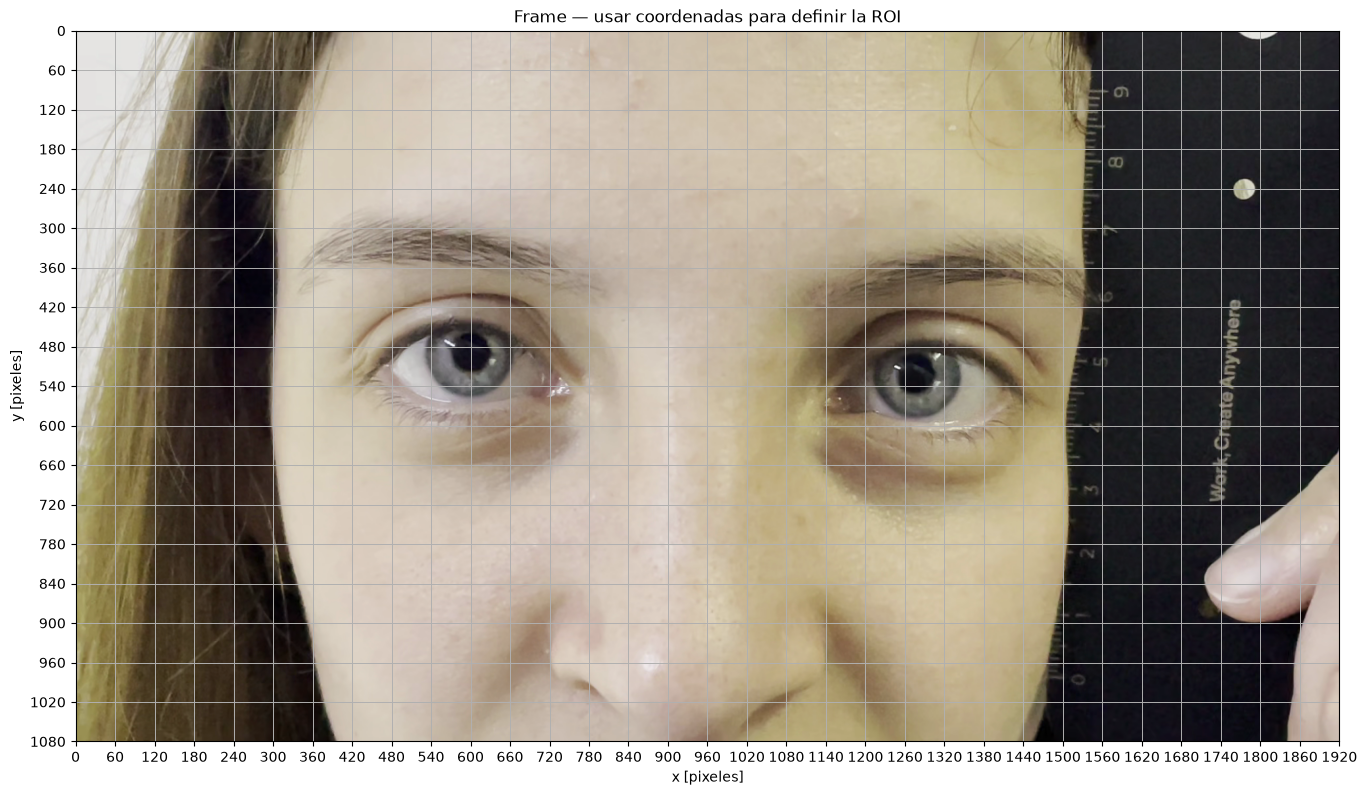

In [6]:
plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
# Grilla cada 50 píxeles
plt.xticks(np.arange(0, width + 1, 60))
plt.yticks(np.arange(0, height + 1, 60))
plt.xlim(0, width)
plt.ylim(height, 0)
plt.grid(True, linewidth=0.7)
plt.xlabel("x [pixeles]")
plt.ylabel("y [pixeles]")
plt.title("Frame — usar coordenadas para definir la ROI")
plt.tight_layout()
plt.show()

 abajo izquierda x=1120 y=600
 abajo derecha x=1440 y=600
 arriba izquierda x=1120 y=480
 arriba derecha x=1440 y=480

In [7]:
x = 1120
y = 470
w = 1440-1120
h = 600-470

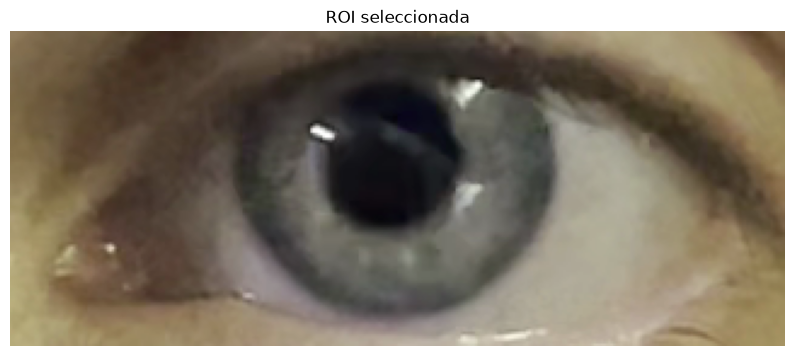

In [8]:
roi_rgb = frame_rgb[y:y+h, x:x+w]

plt.figure(figsize=(10, 6))
plt.imshow(roi_rgb)
plt.axis("off")
plt.title("ROI seleccionada")
plt.show()

In [9]:
roi_height, roi_width = roi_rgb.shape[:2]
# Profundidad de bits por canal
bits_por_canal = roi_rgb.dtype.itemsize * 8

print(f"Ancho de la ROI: {roi_width} píxeles")
print(f"Alto de la ROI: {roi_height} píxeles")
print(f"Canales: {roi_rgb.shape[2]}")
print(f"Profundidad: {bits_por_canal} bits por canal")

Ancho de la ROI: 320 píxeles
Alto de la ROI: 130 píxeles
Canales: 3
Profundidad: 8 bits por canal


Submuestro de la ROI al 50%, 25% y 5%

ROI original: (130, 320, 3)
ROI 50%: (65, 160, 3)
ROI 25%: (32, 80, 3)
ROI 5%: (6, 16, 3)


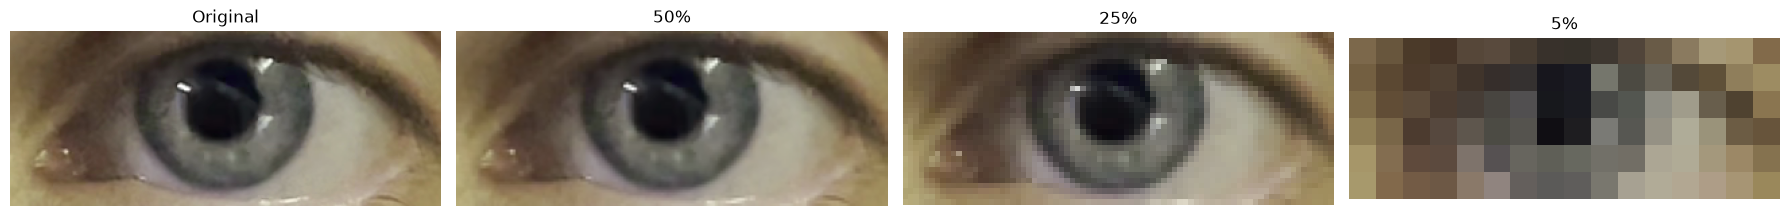

In [10]:
roi_50 = cv2.resize(roi_rgb, None, fx=0.50, fy=0.50, interpolation=cv2.INTER_AREA)
roi_25 = cv2.resize(roi_rgb, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
roi_05 = cv2.resize(roi_rgb, None, fx=0.05, fy=0.05, interpolation=cv2.INTER_AREA)

print("ROI original:", roi_rgb.shape)
print("ROI 50%:", roi_50.shape)
print("ROI 25%:", roi_25.shape)
print("ROI 5%:", roi_05.shape)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(roi_rgb)
axes[0].set_title("Original")

axes[1].imshow(roi_50)
axes[1].set_title("50%")

axes[2].imshow(roi_25)
axes[2].set_title("25%")

axes[3].imshow(roi_05)
axes[3].set_title("5%")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

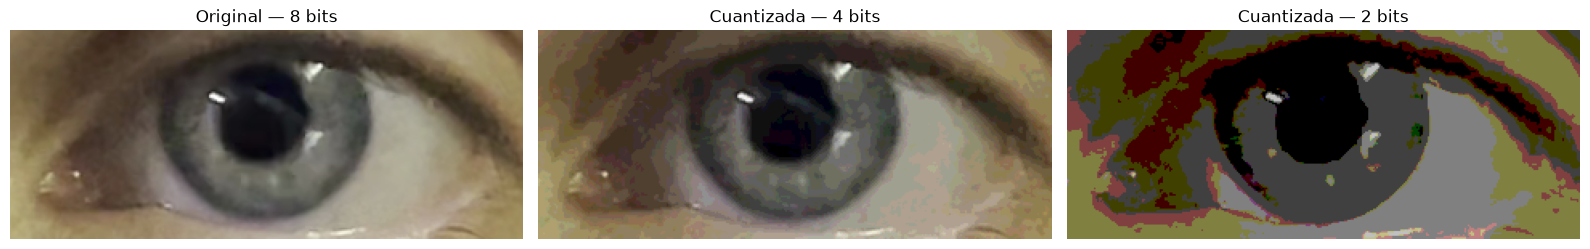

In [11]:
# Cuantización a 4 bits
roi_4bits = (roi_rgb // 16) * 16

# Cuantización a 2 bits
roi_2bits = (roi_rgb // 64) * 64

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(roi_rgb)
axes[0].set_title("Original — 8 bits")

axes[1].imshow(roi_4bits)
axes[1].set_title("Cuantizada — 4 bits")

axes[2].imshow(roi_2bits)
axes[2].set_title("Cuantizada — 2 bits")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Espacios de color --> separar los canales y convertir de RGB a HSV

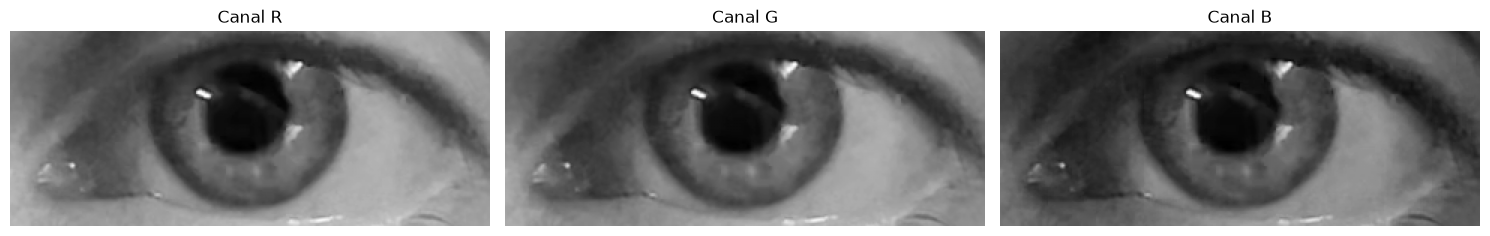

In [12]:
R = roi_rgb[:, :, 0]
G = roi_rgb[:, :, 1]
B = roi_rgb[:, :, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R, cmap="gray")
axes[0].set_title("Canal R")

axes[1].imshow(G, cmap="gray")
axes[1].set_title("Canal G")

axes[2].imshow(B, cmap="gray")
axes[2].set_title("Canal B")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Convetimos la ROI a escala de grises

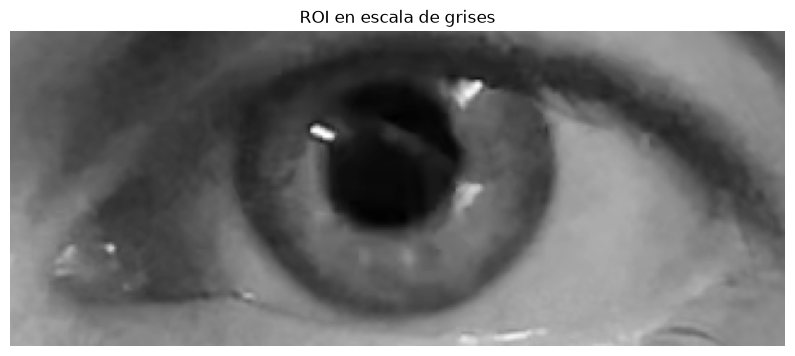

In [13]:
roi_gray = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(10, 6))
plt.imshow(roi_gray, cmap="gray")
plt.axis("off")
plt.title("ROI en escala de grises")
plt.show()

Convertimos a HSV

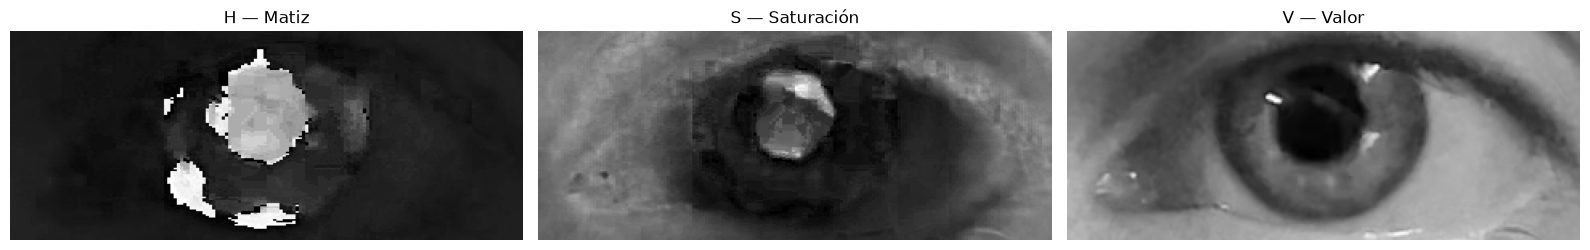

H: 0 → 178
S: 0 → 216
V: 11 → 255


In [14]:
roi_hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_RGB2HSV)

H = roi_hsv[:, :, 0]
S = roi_hsv[:, :, 1]
V = roi_hsv[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(H, cmap="gray")
axes[0].set_title("H — Matiz")

axes[1].imshow(S, cmap="gray")
axes[1].set_title("S — Saturación")

axes[2].imshow(V, cmap="gray")
axes[2].set_title("V — Valor")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"H: {H.min()} → {H.max()}")
print(f"S: {S.min()} → {S.max()}")
print(f"V: {V.min()} → {V.max()}")

HISTOGRAMA

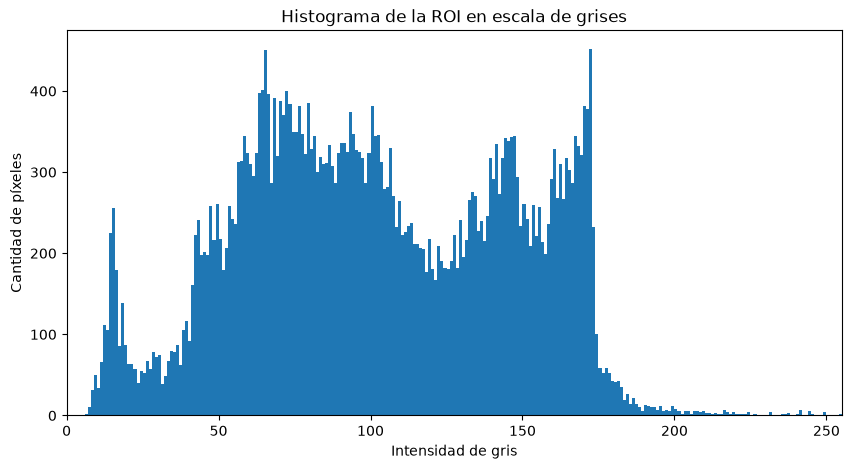

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(roi_gray.ravel(), bins=256, range=(0, 256))

plt.title("Histograma de la ROI en escala de grises")
plt.xlabel("Intensidad de gris")
plt.ylabel("Cantidad de píxeles")
plt.xlim(0, 255)

plt.show()

Modificamos el brillo y el contraste

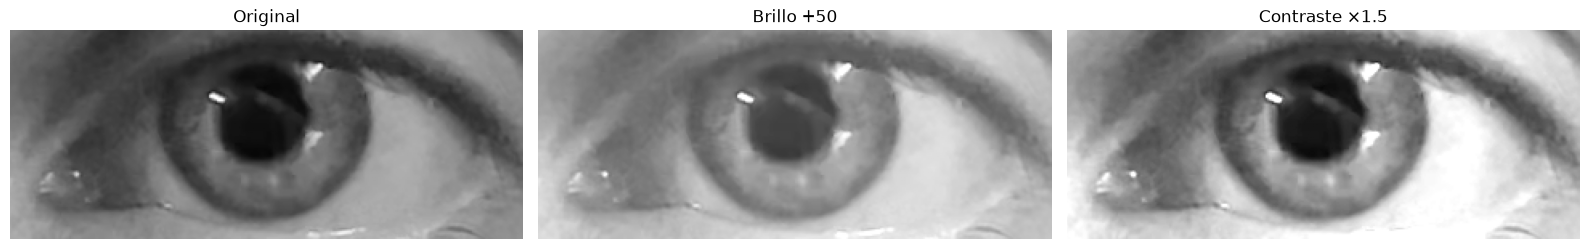

In [16]:
roi_brillo = np.clip(roi_gray.astype(np.int16) + 50, 0, 255).astype(np.uint8)
roi_contraste = np.clip(roi_gray.astype(np.float32) * 1.5, 0, 255).astype(np.uint8)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(roi_brillo, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Brillo +50")

axes[2].imshow(roi_contraste, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Contraste ×1.5")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

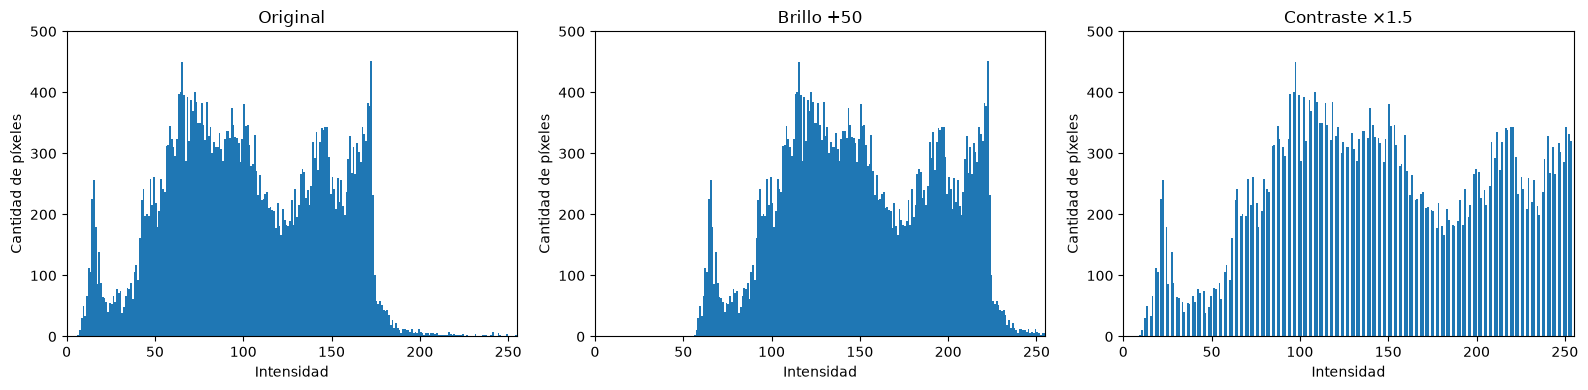

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")

axes[1].hist(roi_brillo.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Brillo +50")

axes[2].hist(roi_contraste.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Contraste ×1.5")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Al aumentarle el brillo sumandole una constante al histograma, se corre todo el espectro en conjunto. En cambio, cuando mejoramos el contraste de la imagen multiplicando por un factor de 1.5, se observa un efecto similar a una ecualización. Los extremos del espectro de nuestra imagen se corren a los extremos del histograma, usándose mejor el rango de 0 a 255. 

Escalado por rango de interés

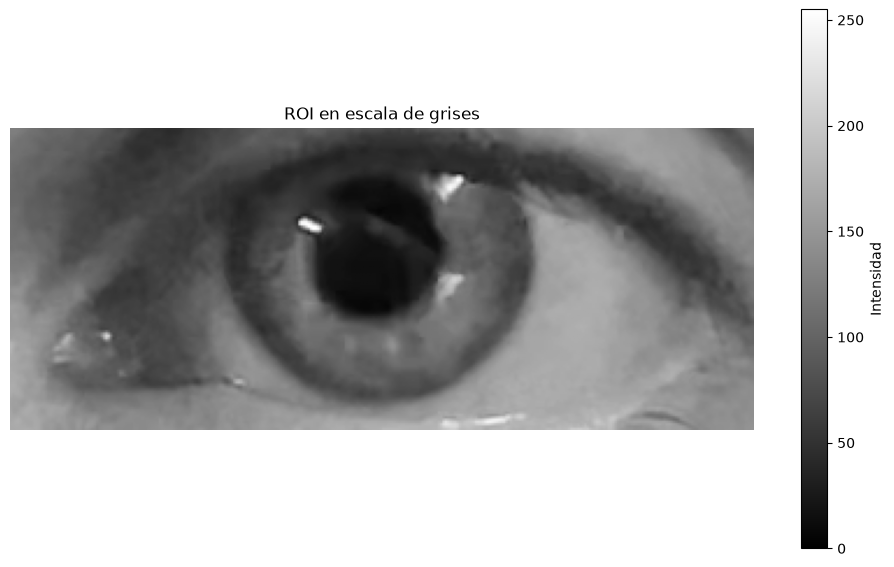

In [18]:
plt.figure(figsize=(12, 7))

plt.imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
plt.colorbar(label="Intensidad")
plt.title("ROI en escala de grises")
plt.axis("off")

plt.show()

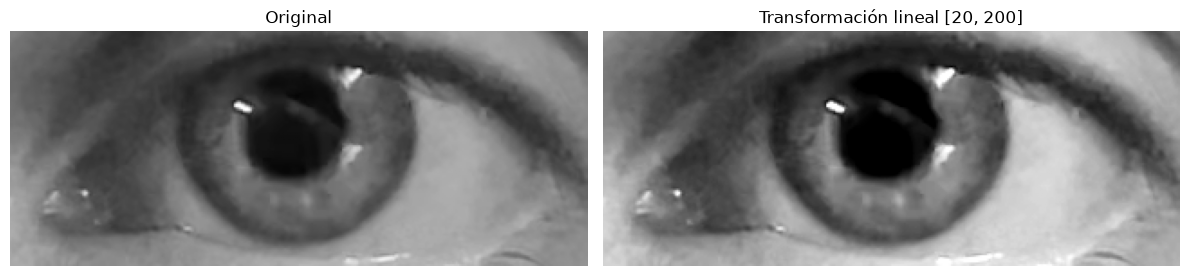

In [19]:
f1 = 20   
f2 = 200 

roi_lineal = (roi_gray.astype(np.float32) - f1) / (f2 - f1) * 255

roi_lineal = np.clip(roi_lineal, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(roi_lineal, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Transformación lineal [{f1:.0f}, {f2:.0f}]")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

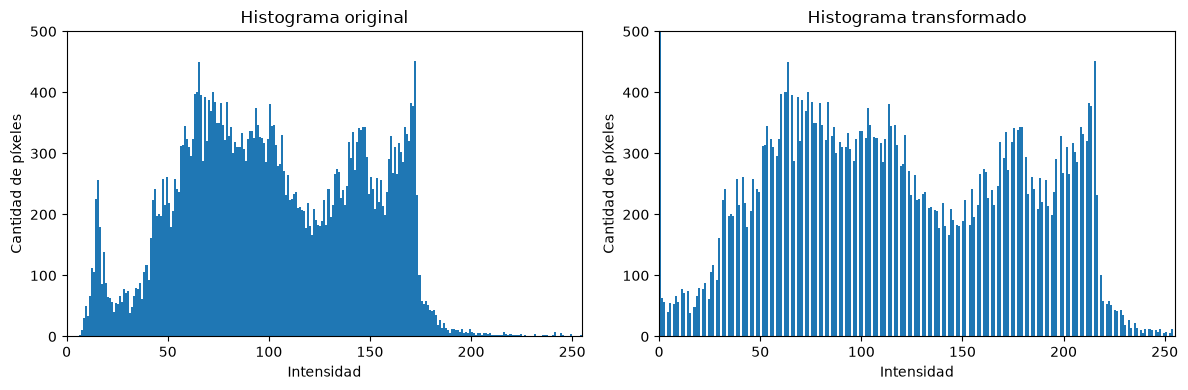

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Histograma original")

axes[1].hist(roi_lineal.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Histograma transformado")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Ecualización del histograma

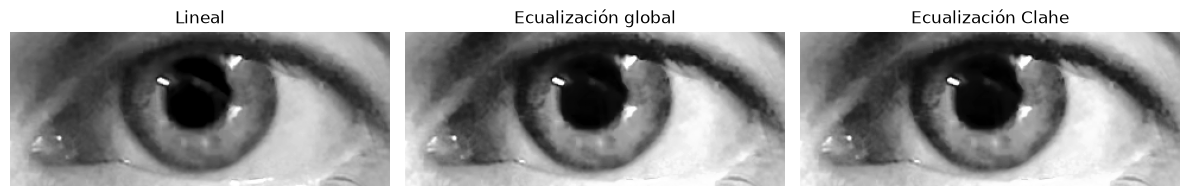

In [21]:
roi_equalizada = cv2.equalizeHist(roi_gray)
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

roi_clahe = clahe.apply(roi_gray)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(roi_lineal, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Lineal")

axes[1].imshow(roi_equalizada, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Ecualización global")

axes[2].imshow(roi_equalizada, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Ecualización Clahe")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

La ecualización global y CLAHE se ven con menor nitidez con respecto a la transformación lineal. Además, hacen que la parte de las pestañas se vean igual de oscuras que la pupila haciendo que se vean más juntas y se distinga menos la separación. 
Se podría decir que se le agrega ruido gaussiano. 

La transformación lineal es la que nos permite distinguir mejor entre la pupila y el iris. CLAHE es la que da peores resultados.

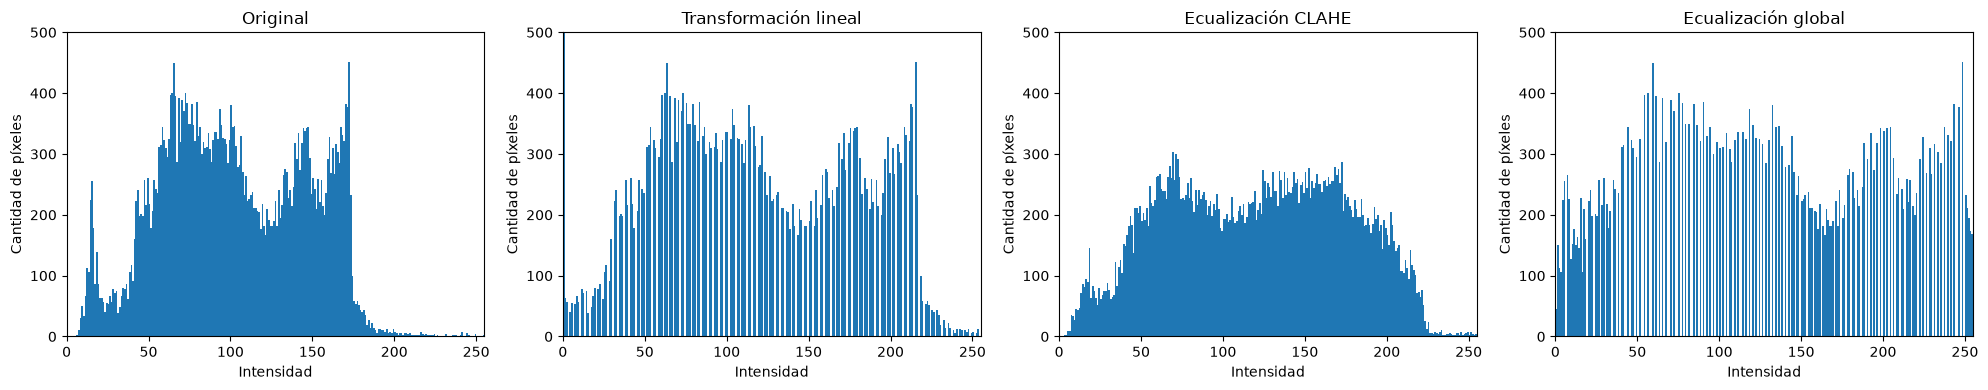

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(roi_gray.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")

axes[1].hist(roi_lineal.ravel(), bins=256, range=(0, 256))
axes[1].set_title("Transformación lineal")

axes[2].hist(roi_clahe.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Ecualización CLAHE")

axes[3].hist(roi_equalizada.ravel(), bins=256, range=(0, 256))
axes[3].set_title("Ecualización global")

for ax in axes:
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 500)
    ax.set_xlabel("Intensidad")
    ax.set_ylabel("Cantidad de píxeles")

plt.tight_layout()
plt.show()

Como en la transformación lineal, se eligen manualmente los extremos del histograma, se observa que en la transformación hay una redistribución general del original. 
CLAHE, por otro lado, al hacer una ecualización local en las regiones donde hay menor variación, el histograma no queda completamente distribuido de 0 a 255. 
En la ecualización global, se observan más amplificados los extremos que en la transformación lineal. Esto explica por qué en la imagen, se ven más oscurecidos ciertas zonas como la de las pestañas. 

Análisis de ruido y filtrado espacial

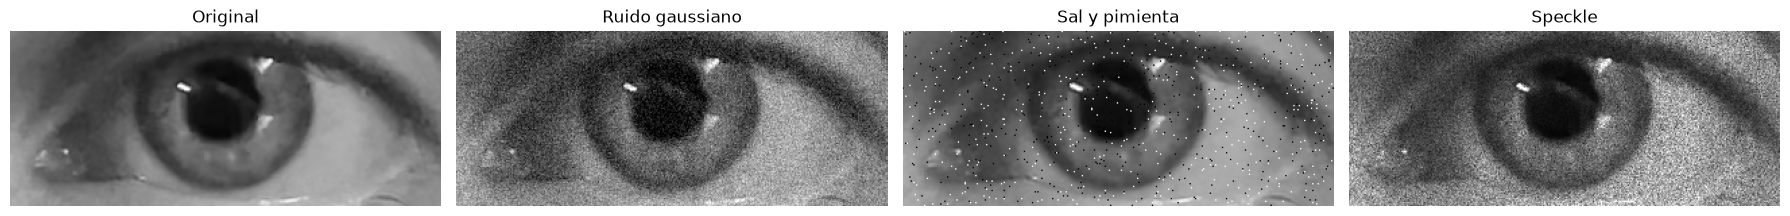

In [25]:
#Gaussiano
img = roi_gray.astype(np.float32)

mu = 0
sigma = 20

ruido_gaussiano = np.random.normal(mu, sigma, img.shape)

img_gaussiano = img + ruido_gaussiano
img_gaussiano = np.clip(img_gaussiano, 0, 255).astype(np.uint8)

#Sal y pimienta
img_sp = roi_gray.copy()

probabilidad = 0.02

random = np.random.random(img_sp.shape)

img_sp[random < probabilidad / 2] = 0
img_sp[random > 1 - probabilidad / 2] = 255

#Speckle
img = roi_gray.astype(np.float32)

sigma_speckle = 0.2

ruido_speckle = np.random.normal(
    0,
    sigma_speckle,
    img.shape
)

img_speckle = img + img * ruido_speckle
img_speckle = np.clip(img_speckle, 0, 255).astype(np.uint8)

#Comparamos los 3
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(roi_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")

axes[1].imshow(img_gaussiano, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Ruido gaussiano")

axes[2].imshow(img_sp, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Sal y pimienta")

axes[3].imshow(img_speckle, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Speckle")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Aplicamos filtros de media, mediana y gaussiano a las 3 imágenes:

In [ ]:
img_gauss_media = cv2.blur(img_gaussiano, (5, 5))
img_sp_media = cv2.blur(img_sp, (5, 5))
img_speckle_media = cv2.blur(img_speckle, (5, 5))

img_gauss_mediana = cv2.medianBlur(img_gaussiano, 5)
img_sp_mediana = cv2.medianBlur(img_sp, 5)
img_speckle_mediana = cv2.medianBlur(img_speckle, 5)

img_gauss_gaussiano = cv2.GaussianBlur(img_gaussiano, (5, 5), 0)

img_sp_gaussiano = cv2.GaussianBlur(img_sp, (5, 5), 0)

img_speckle_gaussiano = cv2.GaussianBlur(img_speckle, (5, 5), 0)


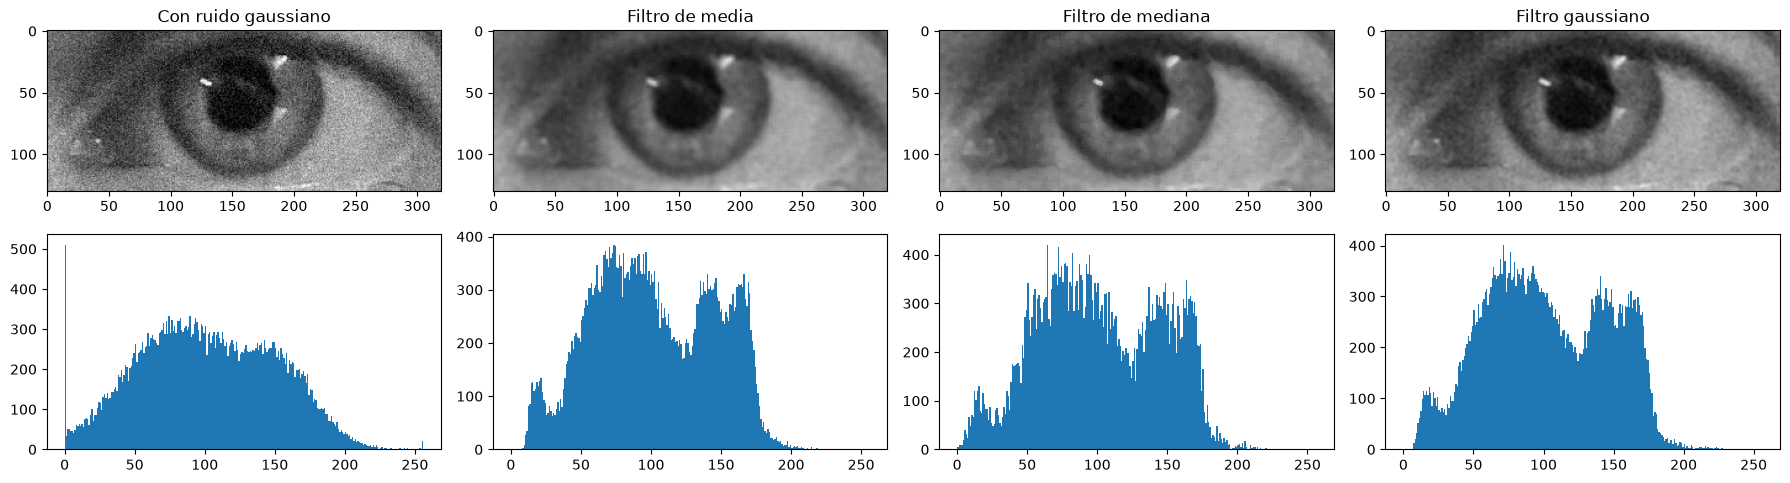

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(18, 5))

axes[0][0].imshow(img_gaussiano, cmap="gray", vmin=0, vmax=255)
axes[0][0].set_title("Con ruido gaussiano")

axes[0][1].imshow(img_gauss_media, cmap="gray", vmin=0, vmax=255)
axes[0][1].set_title("Filtro de media")

axes[0][2].imshow(img_gauss_mediana, cmap="gray", vmin=0, vmax=255)
axes[0][2].set_title("Filtro de mediana")

axes[0][3].imshow(img_gauss_gaussiano, cmap="gray", vmin=0, vmax=255)
axes[0][3].set_title("Filtro gaussiano")

axes[1][0].hist(img_gaussiano.ravel(), bins=256, range=(0, 256))


axes[1][1].hist(img_gauss_media.ravel(), bins=256, range=(0, 256))


axes[1][2].hist(img_gauss_mediana.ravel(), bins=256, range=(0, 256))


axes[1][3].hist(img_gauss_gaussiano.ravel(), bins=256, range=(0, 256))




plt.tight_layout()
plt.show()

Se puede observar que los filtros de media y de mediana, suavizan más la imagen que el gaussiano perdiéndose nitidez. 
En el caso de esta imagen, al ver los histogramas se muestra que los 3 filtros eliminan de forma similar el ruido gaussiano. 

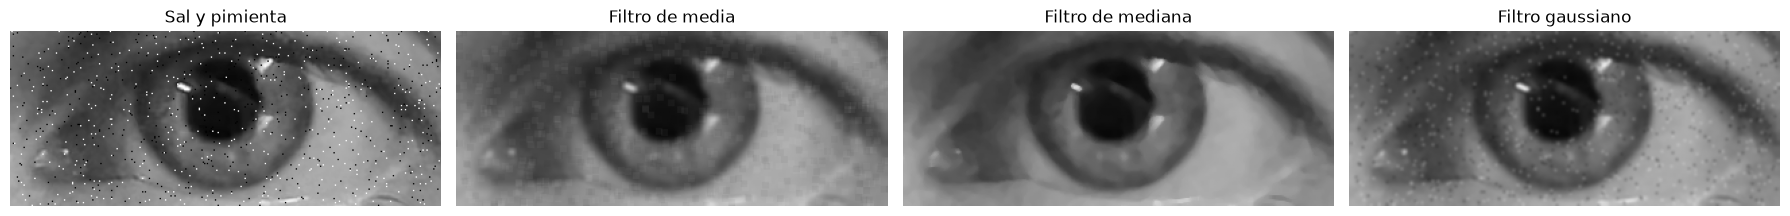

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_sp, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Sal y pimienta")

axes[1].imshow(img_sp_media, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Filtro de media")

axes[2].imshow(img_sp_mediana, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Filtro de mediana")

axes[3].imshow(img_sp_gaussiano, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Filtro gaussiano")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

El filtro que mejor elimina el ruido sal y pimienta es el filtro de mediana como se vio durante el curso. Con los filtros de media y el gaussiano, quedan en la imagen los puntos blancos y oscuros más suavizados pero no se llegan a eliminar por completo. 

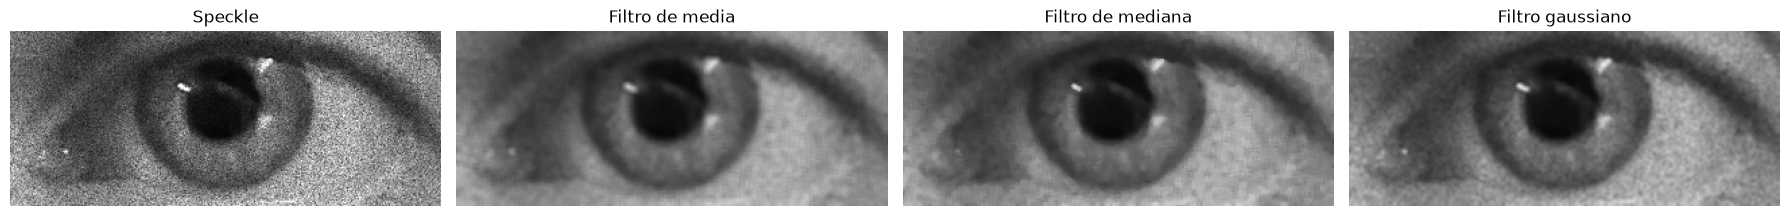

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_speckle, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Speckle")

axes[1].imshow(img_speckle_media, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Filtro de media")

axes[2].imshow(img_speckle_mediana, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Filtro de mediana")

axes[3].imshow(img_speckle_gaussiano, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Filtro gaussiano")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Para el ruido speckle, los filtros de media y mediana dan resultados similares. Con el de media, se obtiene el mayor suavizado pero se pierde bastante nitidez. Mientras que con el filtro gaussiano, se mantiene la nitdez pero se sigue observando considerablemente moteada la imagen. 

Detección de bordes

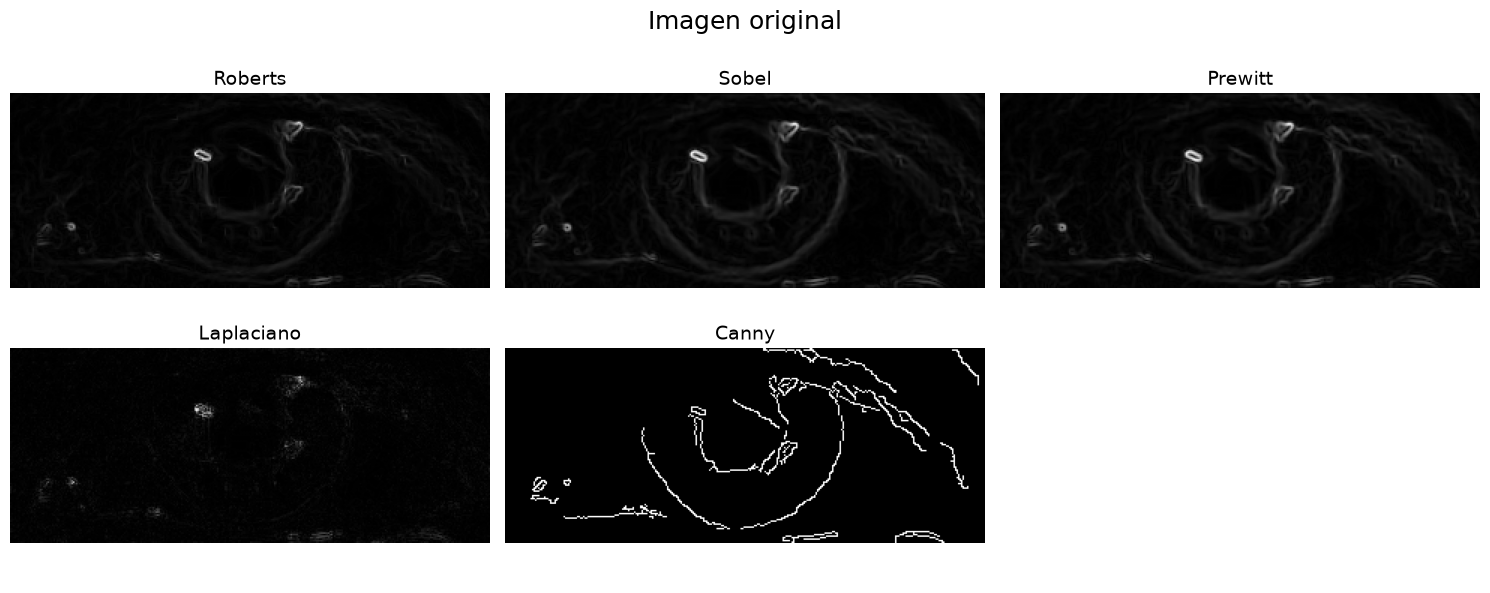

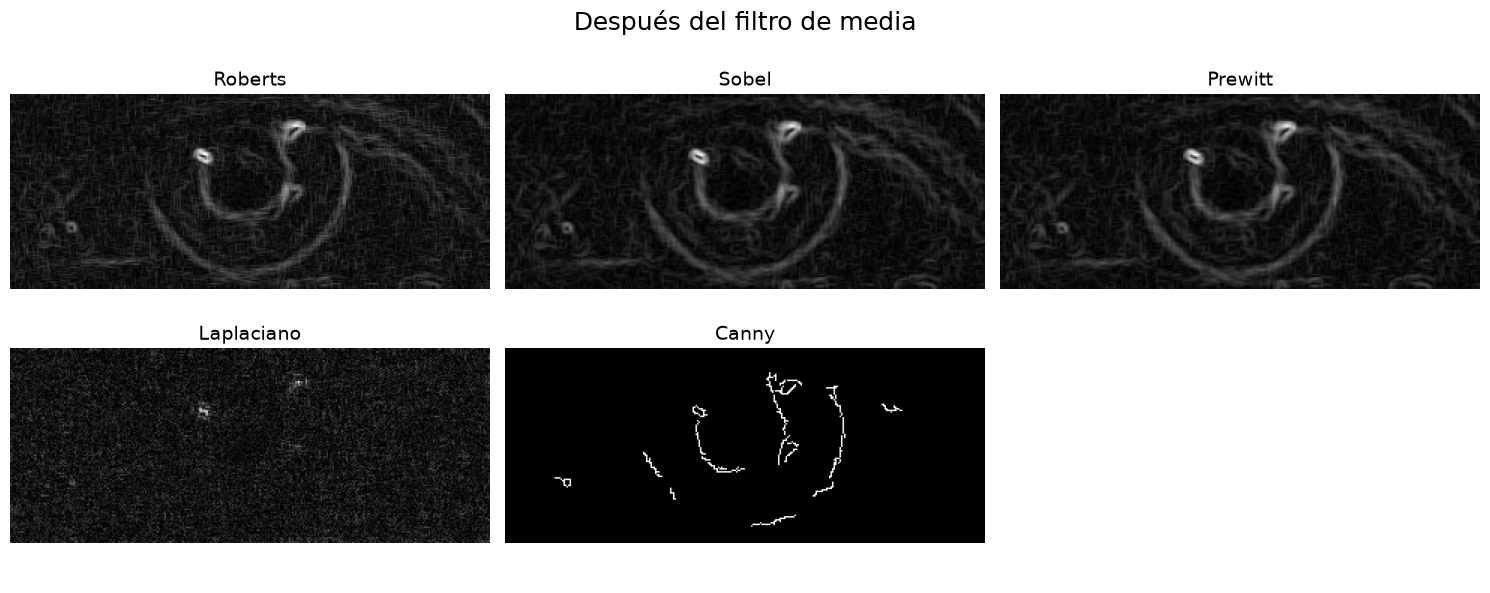

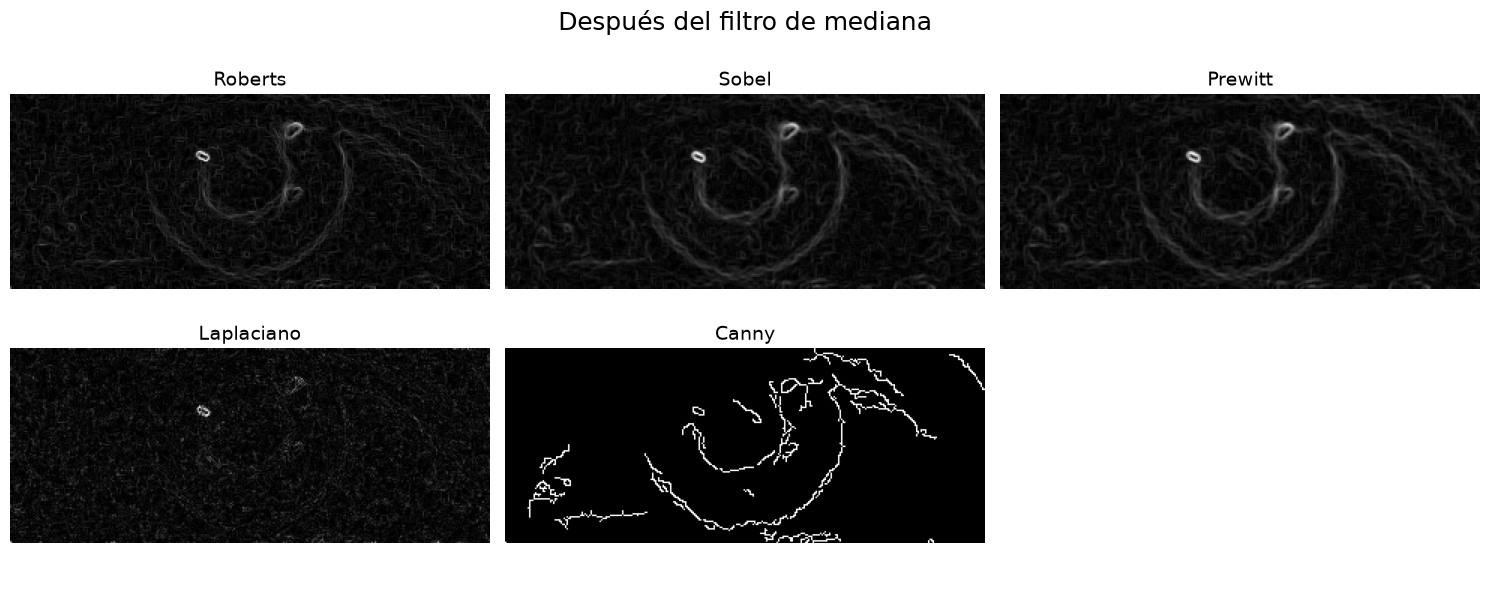

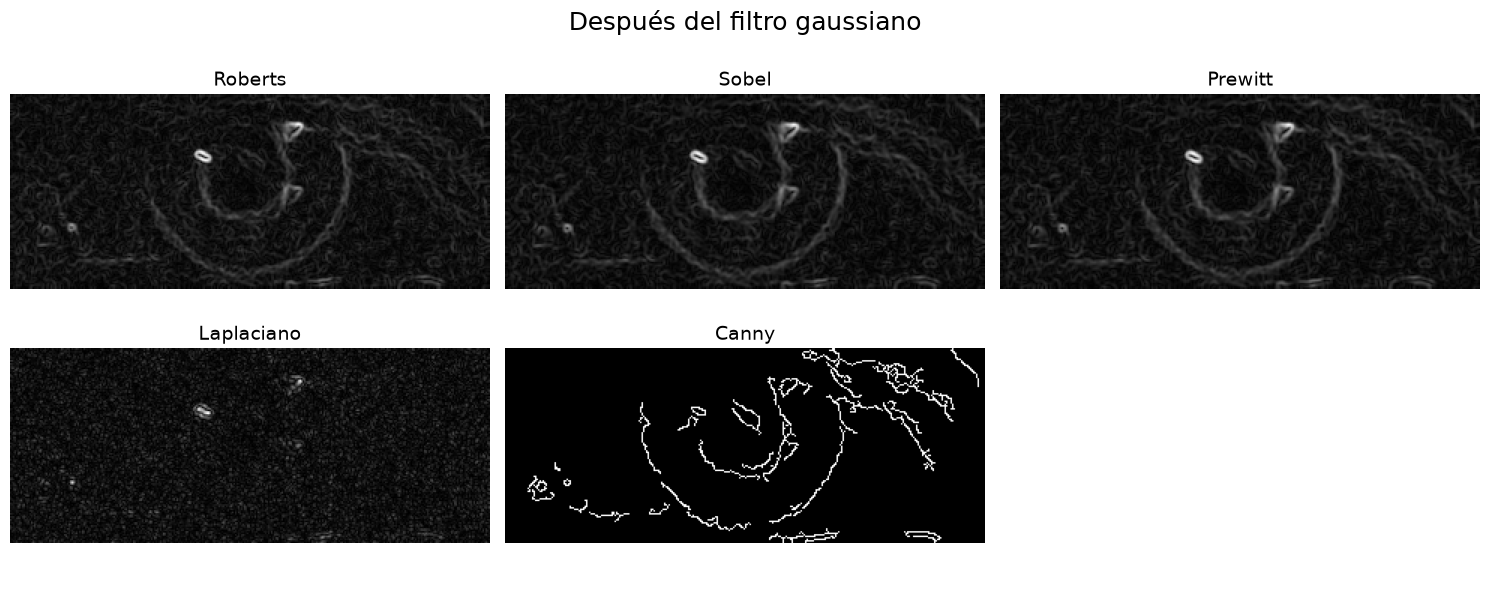

In [49]:
from skimage import filters

def detectar_bordes(img):
    roberts = filters.roberts(img)
    sobel = filters.sobel(img)
    prewitt = filters.prewitt(img)

    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    laplacian = np.abs(laplacian)

    canny = cv2.Canny(img, 50, 150)

    return roberts, sobel, prewitt, laplacian, canny

bordes_original = detectar_bordes(roi_gray)

bordes_media = detectar_bordes(img_gauss_media)
bordes_mediana = detectar_bordes(img_gauss_mediana)
bordes_gaussiano = detectar_bordes(img_gauss_gaussiano)

def mostrar_bordes(bordes, titulo):
    nombres = ["Roberts", "Sobel", "Prewitt", "Laplaciano", "Canny"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.ravel()

    for ax, borde, nombre in zip(axes, bordes, nombres):
        ax.imshow(borde, cmap="gray")
        ax.set_title(nombre, fontsize=14)
        ax.axis("off")

    # Ocultar el sexto espacio
    axes[5].axis("off")

    fig.suptitle(titulo, fontsize=18)
    plt.tight_layout()
    plt.show()

mostrar_bordes(bordes_original, "Imagen original")
mostrar_bordes(bordes_media, "Después del filtro de media")
mostrar_bordes(bordes_mediana, "Después del filtro de mediana")
mostrar_bordes(bordes_gaussiano, "Después del filtro gaussiano")

El detector de bordes que mantiene el borde de la pupila más continua es el Canny. Aún así, no se logra un borde totalmente continuo. 

Con el Canny aplicado sobre la imagen original se obtiene el mejor contorno de ambos la pupila y el iris. 

Transformada de Fourier

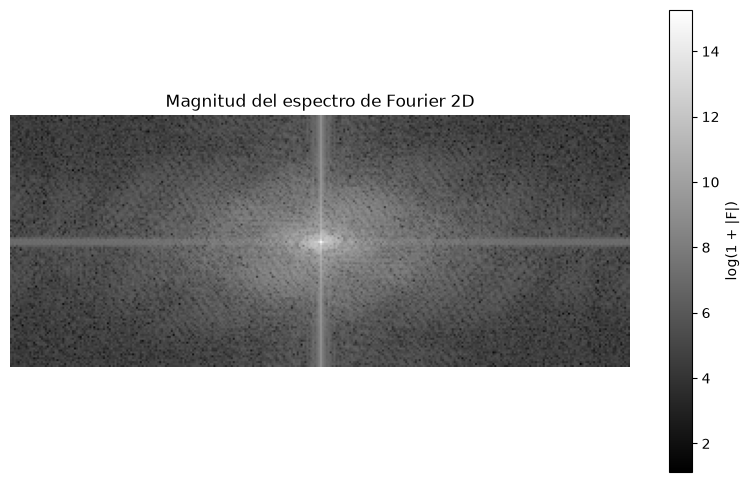

In [50]:
# Transformada de Fourier 2D
F = np.fft.fft2(roi_gray)

# Desplazamos las bajas frecuencias al centro
F_shift = np.fft.fftshift(F)

magnitude = np.abs(F_shift)
magnitude_log = np.log1p(magnitude)

plt.figure(figsize=(10, 6))

plt.imshow(magnitude_log, cmap="gray")
plt.title("Magnitud del espectro de Fourier 2D")
plt.axis("off")
plt.colorbar(label="log(1 + |F|)")

plt.show()

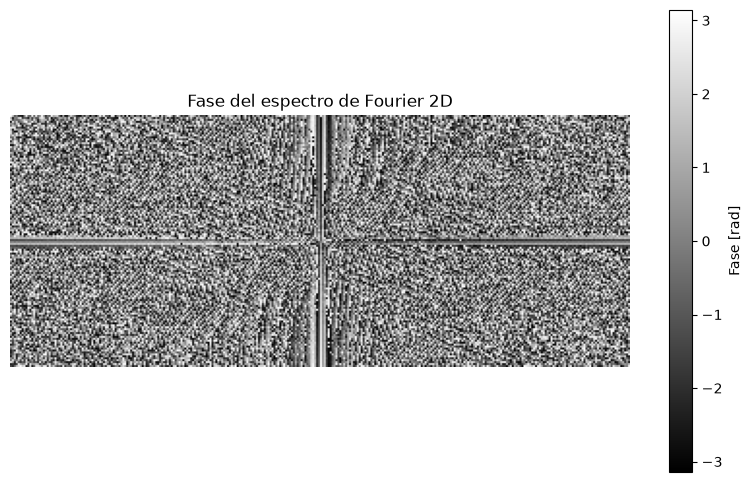

In [51]:
phase = np.angle(F_shift)
plt.figure(figsize=(10, 6))

plt.imshow(phase, cmap="gray")
plt.title("Fase del espectro de Fourier 2D")
plt.axis("off")
plt.colorbar(label="Fase [rad]")

plt.show()

Reconstruimos la imagen a través de la transformada inversa:

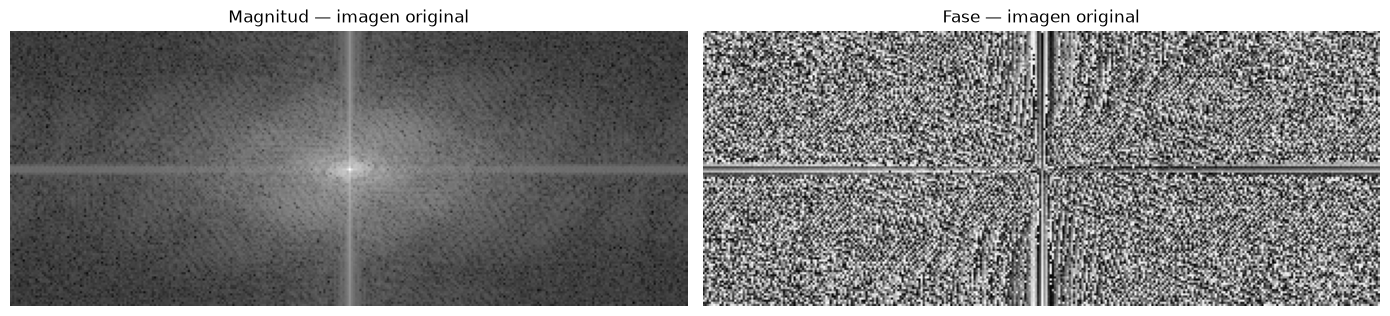

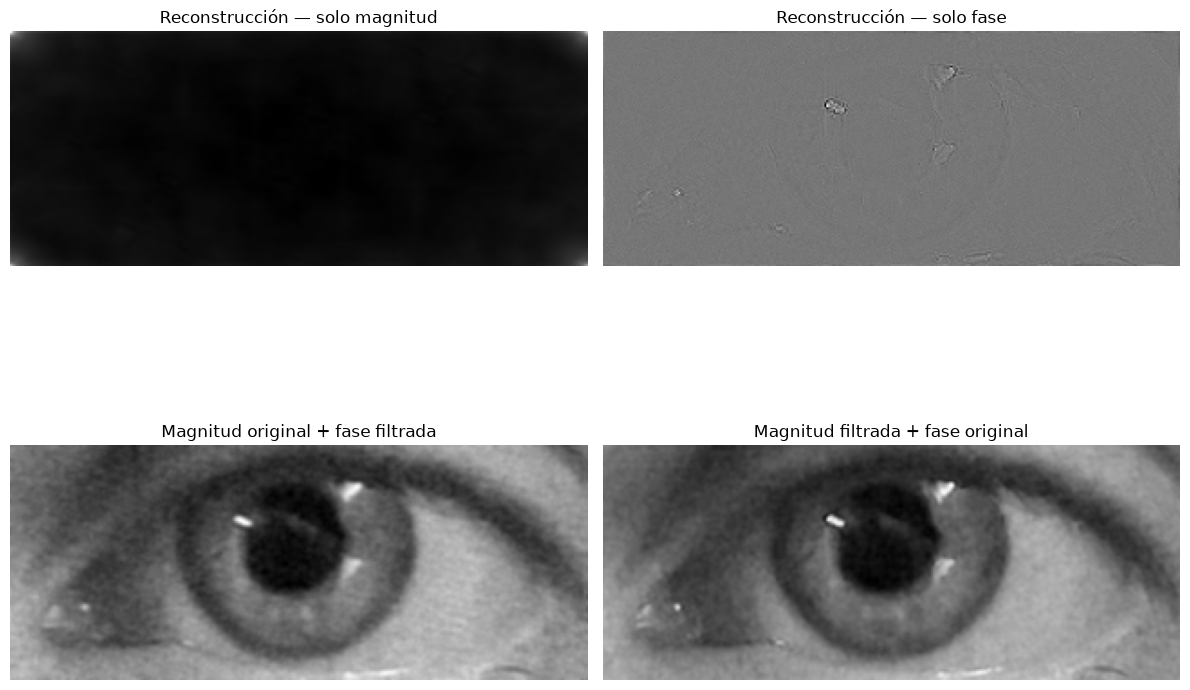

In [54]:
#Tranformada de Fourier de la imagen original

F_original = np.fft.fft2(roi_gray)
F_original_shift = np.fft.fftshift(F_original)

magnitud_original = np.abs(F_original_shift)
fase_original = np.angle(F_original_shift)


# 2. Transformada de Fourier de la imagen con ruido gaussiano + filtro gaussiano

F_filtrada = np.fft.fft2(img_gauss_gaussiano)
F_filtrada_shift = np.fft.fftshift(F_filtrada)

magnitud_filtrada = np.abs(F_filtrada_shift)
fase_filtrada = np.angle(F_filtrada_shift)

# Reconstrucción usando solamente la magnitud

F_solo_magnitud = magnitud_original * np.exp(1j * 0)
recon_magnitud = np.fft.ifft2(
    np.fft.ifftshift(F_solo_magnitud)
)
recon_magnitud = np.real(recon_magnitud)

# Reconstrucción usando solamente la fase

F_solo_fase = np.exp(1j * fase_original)
recon_fase = np.fft.ifft2(
    np.fft.ifftshift(F_solo_fase)
)
recon_fase = np.real(recon_fase)


# Reconstrucción cruzada --> magnitud original + fase filtrada

F_cruzada_1 = magnitud_original * np.exp(1j * fase_filtrada)
recon_cruzada_1 = np.fft.ifft2(
    np.fft.ifftshift(F_cruzada_1)
)
recon_cruzada_1 = np.real(recon_cruzada_1)

# Otra reconstrucción cruzada: magnitud filtrada + fase original

F_cruzada_2 = magnitud_filtrada * np.exp(1j * fase_original)
recon_cruzada_2 = np.fft.ifft2(
    np.fft.ifftshift(F_cruzada_2)
)
recon_cruzada_2 = np.real(recon_cruzada_2)


#Visualización

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(
    np.log1p(magnitud_original),
    cmap="gray"
)
axes[0].set_title("Magnitud — imagen original")

axes[1].imshow(
    fase_original,
    cmap="gray"
)
axes[1].set_title("Fase — imagen original")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(
    recon_magnitud,
    cmap="gray"
)
axes[0, 0].set_title("Reconstrucción — solo magnitud")

axes[0, 1].imshow(
    recon_fase,
    cmap="gray"
)
axes[0, 1].set_title("Reconstrucción — solo fase")

axes[1, 0].imshow(
    recon_cruzada_1,
    cmap="gray"
)
axes[1, 0].set_title(
    "Magnitud original + fase filtrada"
)

axes[1, 1].imshow(
    recon_cruzada_2,
    cmap="gray"
)
axes[1, 1].set_title(
    "Magnitud filtrada + fase original"
)

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

Densidad espectral de potencia

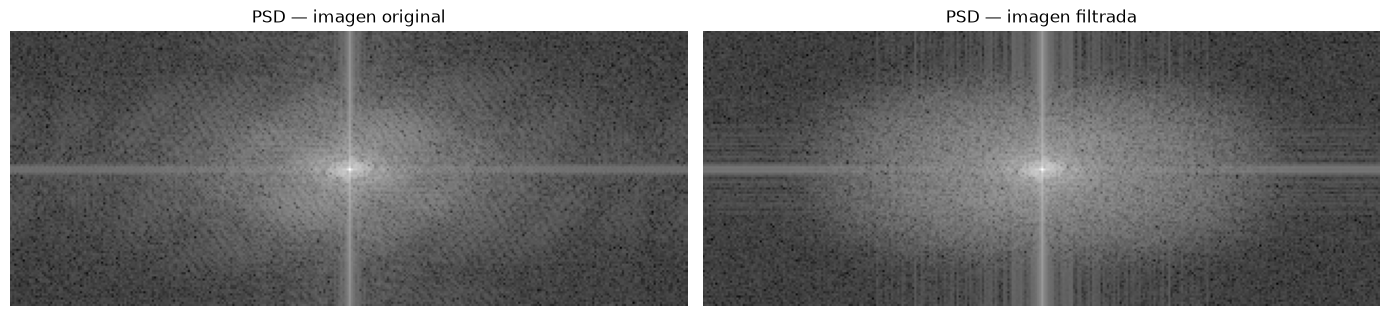

In [58]:
# PSD de la imagen original
PSD_original = np.abs(F_original_shift)**2

# PSD de la imagen filtrada
PSD_filtrada = np.abs(F_filtrada_shift)**2

# Lo pasamos a escala logarítmica para visualizar

PSD_original_log = np.log1p(PSD_original)
PSD_filtrada_log = np.log1p(PSD_filtrada)

# Visualización

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(
    PSD_original_log,
    cmap="gray"
)
axes[0].set_title("PSD — imagen original")
axes[0].axis("off")

axes[1].imshow(
    PSD_filtrada_log,
    cmap="gray"
)
axes[1].set_title("PSD — imagen filtrada")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Se observa que en la PSD de la imagen filtrada, la energía queda más concentrada en la región de las bajas frecuencias. Mientras que en la de la imagen original, se distribute de forma más uniforme. Esto muestra que el filtro gaussiano atenúa las componentes de alta frecuencia de la imagen. 
Sin embargo, como los bordes son regiones donde hay una alta variación de la intensidad y esto implica que en el dominio frecuencial tienen componentes de altas frecuencias, el filtro gaussiano puede hacer que perdamos información de los bordes. 

Filtrado en frecuencia

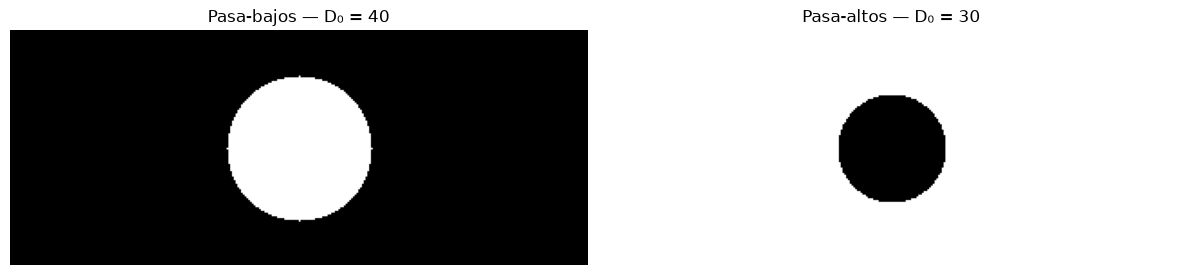

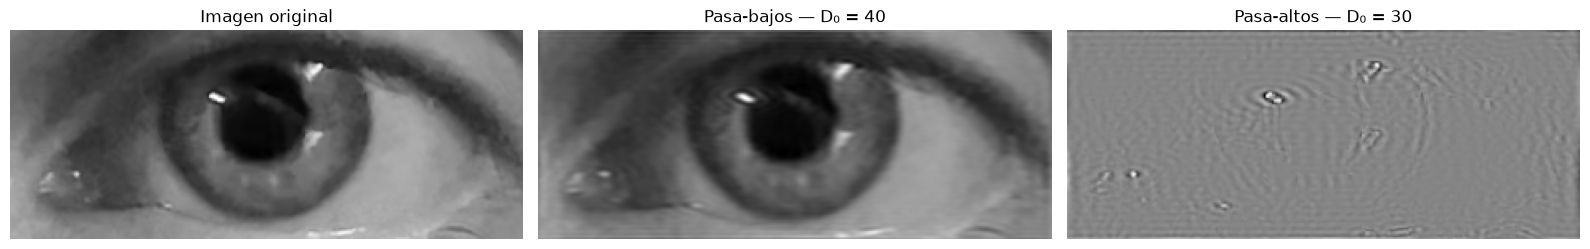

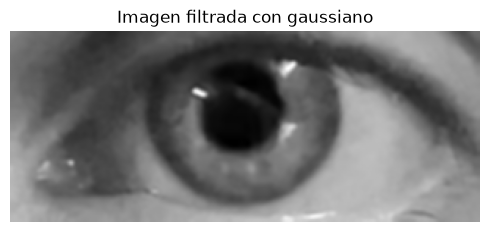

In [79]:
h, w = roi_gray.shape

y, x = np.ogrid[:h, :w]
cy, cx = h // 2, w // 2

# Distancia al centro del espectro
D = np.sqrt((x - cx)**2 + (y - cy)**2)

# Frecuencias de corte
D0_bajos = 40
D0_altos = 30


# FILTRO PASA-BAJOS
filtro_bajos = D <= D0_bajos
F_bajos = F_original_shift * filtro_bajos
img_bajos = np.fft.ifft2(
    np.fft.ifftshift(F_bajos)
)
img_bajos = np.real(img_bajos)

# FILTRO PASA-ALTOS
filtro_altos = D >= D0_altos
F_altos = F_original_shift * filtro_altos
img_altos = np.fft.ifft2(
    np.fft.ifftshift(F_altos)
)
img_altos = np.real(img_altos)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(filtro_bajos, cmap="gray")
axes[0].set_title(f"Pasa-bajos — D₀ = {D0_bajos}")
axes[0].axis("off")

axes[1].imshow(filtro_altos, cmap="gray")
axes[1].set_title(f"Pasa-altos — D₀ = {D0_altos}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


#resultados
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(roi_gray, cmap="gray")
axes[0].set_title("Imagen original")

axes[1].imshow(img_bajos, cmap="gray")
axes[1].set_title(f"Pasa-bajos — D₀ = {D0_bajos}")

axes[2].imshow(img_altos, cmap="gray")
axes[2].set_title(f"Pasa-altos — D₀ = {D0_altos}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# COMPARACIÓN: FILTRADO ESPACIAL VS FILTRADO FRECUENCIAL

img_gaussiano = cv2.GaussianBlur(img, (5, 5), 0)

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

axes.imshow(img_gaussiano, cmap="gray")
axes.set_title("Imagen filtrada con gaussiano")

axes.axis("off")

plt.tight_layout()
plt.show()

Al comparar la imagen original + pasabajos y la imagen filtrada con gaussiano, se observa que con el filtro gaussiano se obtiene mayor suavizado y se pierde nitidez. El filtro pasabajo, logra un suavizado de menor intensidad. Manteniéndose mejor los bordes. 

CáLculo de PSNR y SSIM

In [61]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# PSNR
psnr_media = peak_signal_noise_ratio(roi_gray, img_gauss_media)
psnr_mediana = peak_signal_noise_ratio(roi_gray, img_gauss_mediana)
psnr_gaussiano = peak_signal_noise_ratio(roi_gray, img_gauss_gaussiano)

# SSIM
ssim_media = structural_similarity(roi_gray, img_gauss_media)
ssim_mediana = structural_similarity(roi_gray, img_gauss_mediana)
ssim_gaussiano = structural_similarity(roi_gray, img_gauss_gaussiano)

print("Filtro de media:")
print(f"  PSNR = {psnr_media:.2f} dB")
print(f"  SSIM = {ssim_media:.4f}")

print("\nFiltro de mediana:")
print(f"  PSNR = {psnr_mediana:.2f} dB")
print(f"  SSIM = {ssim_mediana:.4f}")

print("\nFiltro gaussiano:")
print(f"  PSNR = {psnr_gaussiano:.2f} dB")
print(f"  SSIM = {ssim_gaussiano:.4f}")

Filtro de media:
  PSNR = 32.90 dB
  SSIM = 0.8751

Filtro de mediana:
  PSNR = 32.09 dB
  SSIM = 0.8287

Filtro gaussiano:
  PSNR = 32.50 dB
  SSIM = 0.8201


Cuanto mayor es el valor de la PSNR, menor es la diferencia de la imagen filtrada respecto de la imagen original. Y cuanto más se acerque el valor de SSIM a 1, mayor es la simillitud entructural entre las imágenes en cuanto a brillo, contraste y estructura.

Se obtuvo que la imagen filtrada que más se parece a la original es a la que se le aplicó el filtro de media. 